# Load Data

Link to dataset: https://www.kaggle.com/datasets/alistairking/recyclable-and-household-waste-classification

In [8]:
from google.colab import drive
import os

drive.mount('/content/drive')

# Paths
DRIVE_ZIP = '/content/drive/MyDrive/WasteDataset.zip'
DATASET_PATH = '/content/dataset/'
DATASET_ROOT = '/content/dataset/images/images'   # raw source classes
SPLIT_ROOT = '/content/dataset_split'            # output after restructure

os.makedirs(DATASET_PATH, exist_ok=True)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [9]:
# Copy zip from Drive and extract
!cp "{DRIVE_ZIP}" "{DATASET_PATH}"
%cd "{DATASET_PATH}"
!unzip -qq "{os.path.basename(DRIVE_ZIP)}"
%cd /content

/content/dataset
/content


### Data loading and preprocessing functions

In [10]:
import os
import shutil
import random
import hashlib
import matplotlib.pyplot as plt
import tensorflow as tf
from PIL import Image
from collections import defaultdict


# Filesystem
def explore_dataset_folder(root_path, max_files=3):
    """Recursively prints folder structure, capping files shown per folder."""
    for root, dirs, files in os.walk(root_path):
        level = root.replace(root_path, '').count(os.sep)
        indent = ' ' * 4 * level
        print(f"{indent}[{os.path.basename(root)}/]")
        sub_indent = ' ' * 4 * (level + 1)
        for f in files[:max_files]:
            print(f"{sub_indent}{f}")
        if len(files) > max_files:
            print(f"{sub_indent}... and {len(files) - max_files} more files")


# Hashing
def hash_image(path):
    """Returns an MD5 hash of the image pixel content, normalized to RGB."""
    with Image.open(path) as img:
        return hashlib.md5(img.convert("RGB").tobytes()).hexdigest()


# Raw dataset duplicate check (before splitting)
def check_raw_duplicates(src_root):
    """
    Checks for duplicate images within each class across its subfolders
    (e.g. default/ vs real_world/) in the original unsplit dataset.
    Returns a dict of {class_name: [(path_a, path_b), ...]} for all duplicates found.
    """
    print("Hashing raw dataset...\n")
    all_duplicates = {}
    total_dupes = 0

    for class_name in sorted(os.listdir(src_root)):
        class_path = os.path.join(src_root, class_name)
        if not os.path.isdir(class_path):
            continue

        hash_to_path = {}
        dupes = []

        for subfolder in os.listdir(class_path):
            subfolder_path = os.path.join(class_path, subfolder)
            if not os.path.isdir(subfolder_path):
                continue
            for fname in os.listdir(subfolder_path):
                if not fname.lower().endswith((".png", ".jpg", ".jpeg")):
                    continue
                fpath = os.path.join(subfolder_path, fname)
                try:
                    h = hash_image(fpath)
                    if h in hash_to_path:
                        dupes.append((hash_to_path[h], fpath))
                    else:
                        hash_to_path[h] = fpath
                except Exception as e:
                    print(f"  Skipping {fpath}: {e}")

        if dupes:
            all_duplicates[class_name] = dupes
            total_dupes += len(dupes)
            print(f"  [{class_name}]: {len(dupes)} duplicate(s)")

    print(f"\n=== Summary ===")
    if total_dupes == 0:
        print("No duplicates found in raw dataset.")
    else:
        print(f"Found {total_dupes} duplicate image(s) across {len(all_duplicates)} class(es).")
        print("These will be removed during restructure_dataset().")

    return all_duplicates


def plot_raw_duplicates(all_duplicates, num_examples=5):
    """
    Plots duplicate image pairs found in the raw dataset side by side.

    Args:
        all_duplicates: dict returned by check_raw_duplicates()
        num_examples:   max number of pairs to plot
    """
    pairs = []
    for class_name, dupes in all_duplicates.items():
        for path_a, path_b in dupes:
            pairs.append((class_name, path_a, path_b))
            if len(pairs) >= num_examples:
                break
        if len(pairs) >= num_examples:
            break

    if not pairs:
        print("No duplicates to plot.")
        return

    fig, axes = plt.subplots(len(pairs), 2, figsize=(6, 3 * len(pairs)))
    fig.suptitle("Duplicate Images in Raw Dataset", fontsize=14, fontweight="bold", y=1.01)

    if len(pairs) == 1:
        axes = [axes]

    for i, (class_name, path_a, path_b) in enumerate(pairs):
        for ax, path, subfolder_label in zip(
            axes[i],
            [path_a, path_b],
            [os.path.basename(os.path.dirname(path_a)),
             os.path.basename(os.path.dirname(path_b))]
        ):
            ax.imshow(Image.open(path).convert("RGB"))
            ax.axis("off")
            ax.set_title(
                f"[{class_name}]\n{subfolder_label}\n{os.path.basename(path)}",
                fontsize=8
            )

    plt.tight_layout()
    plt.show()


# Restructure and deduplicate dataset
def restructure_dataset(src_root, dst_root, train=0.8, val=0.1, test=0.1, seed=42):
    """
    Converts:
        src_root/{class_name}/{subfolder}/images...
    Into:
        dst_root/train/{class_name}/images...
        dst_root/val/{class_name}/images...
        dst_root/test/{class_name}/images...

    Deduplicates globally across all classes before splitting, so identical
    images (even across classes) always land in the same split.
    """
    assert abs(train + val + test - 1.0) < 1e-6, "Splits must sum to 1.0"
    random.seed(seed)

    print("Hashing all images for global deduplication...")
    global_seen   = {}  # {hash: (class_name, path)}
    class_buckets = defaultdict(list)  # {class_name: [unique paths]}

    for class_name in sorted(os.listdir(src_root)):
        class_path = os.path.join(src_root, class_name)
        if not os.path.isdir(class_path):
            continue
        for subfolder in os.listdir(class_path):
            subfolder_path = os.path.join(class_path, subfolder)
            if not os.path.isdir(subfolder_path):
                continue
            for fname in os.listdir(subfolder_path):
                if not fname.lower().endswith((".png", ".jpg", ".jpeg")):
                    continue
                fpath = os.path.join(subfolder_path, fname)
                try:
                    h = hash_image(fpath)
                    if h in global_seen:
                        continue  # skip global duplicate
                    global_seen[h] = (class_name, fpath)
                    class_buckets[class_name].append(fpath)
                except Exception as e:
                    print(f"  Skipping {fpath}: {e}")

    print(f"Found {len(global_seen)} unique images across {len(class_buckets)} classes.\n")

    for class_name, images in class_buckets.items():
        random.shuffle(images)
        n       = len(images)
        n_train = int(n * train)
        n_val   = int(n * val)

        splits = {
            "train": images[:n_train],
            "val":   images[n_train:n_train + n_val],
            "test":  images[n_train + n_val:]
        }

        counts = {}
        for split_name, files in splits.items():
            out_dir = os.path.join(dst_root, split_name, class_name)
            os.makedirs(out_dir, exist_ok=True)
            for src_path in files:
                subfolder = os.path.basename(os.path.dirname(src_path))
                fname     = f"{subfolder}_{os.path.basename(src_path)}"
                shutil.copy(src_path, os.path.join(out_dir, fname))
            counts[split_name] = len(files)

        print(f"  {class_name}: {counts['train']} train | {counts['val']} val | {counts['test']} test  ({n} unique)")


# Leakage check on split dataset
def check_leakage_by_hash(dataset_root):
    """
    Checks for data leakage across train/val/test splits by comparing MD5
    hashes. Catches duplicates even if they have different filenames.
    """
    splits = ["train", "val", "test"]
    print("Hashing split dataset...\n")

    split_hashes = {}
    for split in splits:
        split_hashes[split] = {}
        split_dir = os.path.join(dataset_root, split)
        for class_name in sorted(os.listdir(split_dir)):
            class_dir = os.path.join(split_dir, class_name)
            if not os.path.isdir(class_dir):
                continue
            for fname in os.listdir(class_dir):
                fpath = os.path.join(class_dir, fname)
                try:
                    h = hash_image(fpath)
                    split_hashes[split][h] = (class_name, fname)
                except Exception as e:
                    print(f"  Skipping {fpath}: {e}")
        print(f"  {split}: {len(split_hashes[split])} unique images")

    pairs         = [("train", "val"), ("train", "test"), ("val", "test")]
    leakage_found = False

    for split_a, split_b in pairs:
        overlap = set(split_hashes[split_a]) & set(split_hashes[split_b])
        print(f"\n--- {split_a} vs {split_b} ---")
        if not overlap:
            print("  No leakage found.")
        else:
            leakage_found = True
            print(f"  WARNING: {len(overlap)} duplicate(s) found:")
            for h in sorted(overlap)[:5]:
                ca, fa = split_hashes[split_a][h]
                cb, fb = split_hashes[split_b][h]
                print(f"    [{ca}] {fa}  ==  [{cb}] {fb}")
            if len(overlap) > 5:
                print(f"    ... and {len(overlap) - 5} more")

    print("\n=== Summary ===")
    if leakage_found:
        print("WARNING: Leakage detected. Re-run restructure_dataset() to fix.")
    else:
        print("No data leakage detected. Splits are clean.")


# Dataloader helpers
def count_images(dataset):
    """Counts total images in a batched tf.data.Dataset."""
    count = 0
    for images, _ in dataset:
        count += images.shape[0]
    return count


# Class merging configuration
# Goes from 30 to 23 classes by combining visually ambiguous categories.
MERGE_MAP = {
    "aluminum_food_cans":         "metal_cans",
    "aluminum_soda_cans":         "metal_cans",
    "steel_food_cans":            "metal_cans",
    "cardboard_boxes":            "cardboard",
    "cardboard_packaging":        "cardboard",
    "plastic_soda_bottles":       "plastic_beverage_bottles",
    "plastic_water_bottles":      "plastic_beverage_bottles",
    "glass_beverage_bottles":     "glass_containers",
    "glass_food_jars":            "glass_containers",
    "glass_cosmetic_containers":  "glass_containers",
    "paper_cups":                 "disposable_cups",
    "styrofoam_cups":             "disposable_cups",
}


def get_merged_class(original_name):
    """Returns the merged class name if applicable, else returns the original."""
    return MERGE_MAP.get(original_name, original_name)


# Restructure with class merging applied
def restructure_dataset_merged(src_root, dst_root, merge_map=None,
                                train=0.8, val=0.1, test=0.1, seed=42):
    if merge_map is None:
        merge_map = MERGE_MAP
    assert abs(train + val + test - 1.0) < 1e-6, "Splits must sum to 1.0"
    random.seed(seed)

    print("Hashing all images for global deduplication...")
    global_seen   = {}                  # {hash: (merged_class_name, path)}
    class_buckets = defaultdict(list)   # {merged_class_name: [unique paths]}

    for class_name in sorted(os.listdir(src_root)):
        class_path = os.path.join(src_root, class_name)
        if not os.path.isdir(class_path):
            continue

        # Apply the merge: this folder's images go into the merged bucket
        merged_name = merge_map.get(class_name, class_name)

        for subfolder in os.listdir(class_path):
            subfolder_path = os.path.join(class_path, subfolder)
            if not os.path.isdir(subfolder_path):
                continue
            for fname in os.listdir(subfolder_path):
                if not fname.lower().endswith((".png", ".jpg", ".jpeg")):
                    continue
                fpath = os.path.join(subfolder_path, fname)
                try:
                    h = hash_image(fpath)
                    if h in global_seen:
                        continue  # skip global duplicate
                    global_seen[h] = (merged_name, fpath)
                    class_buckets[merged_name].append(fpath)
                except Exception as e:
                    print(f"  Skipping {fpath}: {e}")

    print(f"Found {len(global_seen)} unique images across {len(class_buckets)} merged classes.\n")

    # Print which originals were merged into what
    reverse_map = defaultdict(list)
    for orig, merged in merge_map.items():
        reverse_map[merged].append(orig)
    if reverse_map:
        print("Applied merges:")
        for merged, originals in reverse_map.items():
            print(f"  {merged} <- {' + '.join(originals)}")
        print()

    for class_name, images in class_buckets.items():
        random.shuffle(images)
        n       = len(images)
        n_train = int(n * train)
        n_val   = int(n * val)

        splits = {
            "train": images[:n_train],
            "val":   images[n_train:n_train + n_val],
            "test":  images[n_train + n_val:]
        }

        counts = {}
        for split_name, files in splits.items():
            out_dir = os.path.join(dst_root, split_name, class_name)
            os.makedirs(out_dir, exist_ok=True)
            for src_path in files:
                # Keep original class name in filename for traceability
                orig_class = os.path.basename(os.path.dirname(os.path.dirname(src_path)))
                subfolder  = os.path.basename(os.path.dirname(src_path))
                fname      = f"{orig_class}_{subfolder}_{os.path.basename(src_path)}"
                shutil.copy(src_path, os.path.join(out_dir, fname))
            counts[split_name] = len(files)

        print(f"  {class_name}: {counts['train']} train | {counts['val']} val | {counts['test']} test  ({n} unique)")


### Explore raw dataset structure

In [11]:
explore_dataset_folder(DATASET_ROOT, max_files=3)

[images/]
    [steel_food_cans/]
        [real_world/]
            Image_236.png
            Image_217.png
            Image_122.png
            ... and 247 more files
        [default/]
            Image_236.png
            Image_217.png
            Image_122.png
            ... and 247 more files
    [plastic_food_containers/]
        [real_world/]
            Image_236.png
            Image_217.png
            Image_122.png
            ... and 247 more files
        [default/]
            Image_236.png
            Image_217.png
            Image_122.png
            ... and 247 more files
    [shoes/]
        [real_world/]
            Image_236.png
            Image_217.png
            Image_122.png
            ... and 247 more files
        [default/]
            Image_236.png
            Image_217.png
            Image_122.png
            ... and 247 more files
    [tea_bags/]
        [real_world/]
            Image_236.png
            Image_217.png
            Image_122.png
      

### Check Raw Dataset for Duplicates

Before splitting, check for duplicate images between the `default/` and `real_world/`
subfolders within each class. These would cause data leakage if not removed before splitting.

In [12]:
raw_duplicates = check_raw_duplicates(DATASET_ROOT)

Hashing raw dataset...

  [aerosol_cans]: 147 duplicate(s)
  [aluminum_food_cans]: 118 duplicate(s)
  [aluminum_soda_cans]: 110 duplicate(s)
  [cardboard_boxes]: 102 duplicate(s)
  [cardboard_packaging]: 124 duplicate(s)
  [clothing]: 9 duplicate(s)
  [coffee_grounds]: 133 duplicate(s)
  [disposable_plastic_cutlery]: 139 duplicate(s)
  [eggshells]: 94 duplicate(s)
  [food_waste]: 201 duplicate(s)
  [glass_beverage_bottles]: 168 duplicate(s)
  [glass_cosmetic_containers]: 161 duplicate(s)
  [glass_food_jars]: 137 duplicate(s)
  [magazines]: 54 duplicate(s)
  [newspaper]: 14 duplicate(s)
  [office_paper]: 64 duplicate(s)
  [paper_cups]: 94 duplicate(s)
  [plastic_cup_lids]: 134 duplicate(s)
  [plastic_detergent_bottles]: 146 duplicate(s)
  [plastic_food_containers]: 153 duplicate(s)
  [plastic_shopping_bags]: 127 duplicate(s)
  [plastic_soda_bottles]: 154 duplicate(s)
  [plastic_straws]: 96 duplicate(s)
  [plastic_trash_bags]: 134 duplicate(s)
  [plastic_water_bottles]: 96 duplicate(s)
 

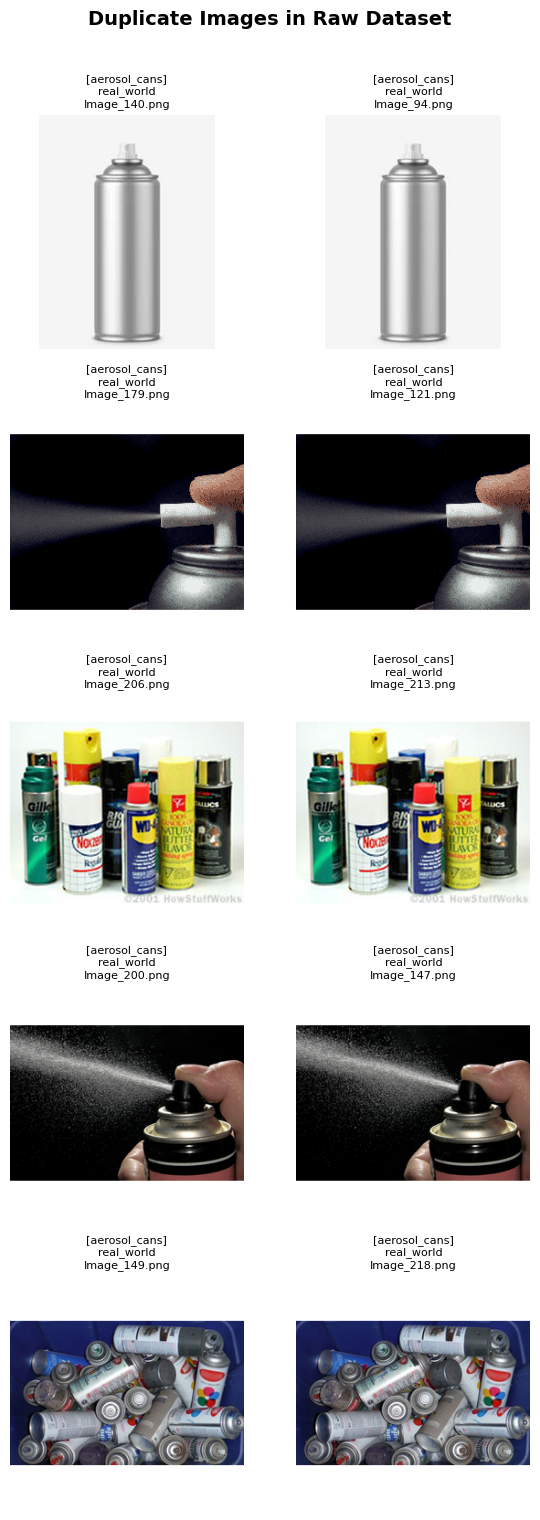

In [13]:
plot_raw_duplicates(raw_duplicates, num_examples=5)

### Restructure Dataset

Splits the dataset into `train/`, `val/`, and `test/` folders while globally
deduplicating by image hash so no identical image appears in more than one split.

In [14]:
shutil.rmtree(SPLIT_ROOT, ignore_errors=True)  # wipe any previous split

# Apply class merging during preprocessing (30 -> 23 classes)
restructure_dataset_merged(
    src_root=DATASET_ROOT,
    dst_root=SPLIT_ROOT,
    merge_map=MERGE_MAP,
    train=0.8,
    val=0.1,
    test=0.1,
    seed=42
)

Hashing all images for global deduplication...
Found 11263 unique images across 23 merged classes.

Applied merges:
  metal_cans <- aluminum_food_cans + aluminum_soda_cans + steel_food_cans
  cardboard <- cardboard_boxes + cardboard_packaging
  plastic_beverage_bottles <- plastic_soda_bottles + plastic_water_bottles
  glass_containers <- glass_beverage_bottles + glass_food_jars + glass_cosmetic_containers
  disposable_cups <- paper_cups + styrofoam_cups

  aerosol_cans: 282 train | 35 val | 36 test  (353 unique)
  metal_cans: 821 train | 102 val | 104 test  (1027 unique)
  cardboard: 530 train | 66 val | 67 test  (663 unique)
  clothing: 392 train | 49 val | 50 test  (491 unique)
  coffee_grounds: 293 train | 36 val | 38 test  (367 unique)
  disposable_plastic_cutlery: 288 train | 36 val | 37 test  (361 unique)
  eggshells: 324 train | 40 val | 42 test  (406 unique)
  food_waste: 239 train | 29 val | 31 test  (299 unique)
  glass_containers: 826 train | 103 val | 104 test  (1033 unique

### Verify No Data Leakage in Split Dataset

In [15]:
check_leakage_by_hash(SPLIT_ROOT)

Hashing split dataset...

  train: 8999 unique images
  val: 1115 unique images
  test: 1149 unique images

--- train vs val ---
  No leakage found.

--- train vs test ---
  No leakage found.

--- val vs test ---
  No leakage found.

=== Summary ===
No data leakage detected. Splits are clean.


### Create dataloaders

In [16]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

# Load train first to extract class_names before prefetch wraps it
_train_base = tf.keras.utils.image_dataset_from_directory(
    os.path.join(SPLIT_ROOT, "train"),
    seed=SEED, image_size=IMG_SIZE, batch_size=BATCH_SIZE, label_mode="categorical"
)

# Get class names
class_names  = _train_base.class_names
idx_to_class = {i: name for i, name in enumerate(class_names)}

# Make the dataloaders
train_dataset = _train_base.prefetch(tf.data.AUTOTUNE)

val_dataset = tf.keras.utils.image_dataset_from_directory(
    os.path.join(SPLIT_ROOT, "val"),
    seed=SEED, image_size=IMG_SIZE, batch_size=BATCH_SIZE, label_mode="categorical"
).prefetch(tf.data.AUTOTUNE)

test_dataset = tf.keras.utils.image_dataset_from_directory(
    os.path.join(SPLIT_ROOT, "test"),
    seed=SEED, image_size=IMG_SIZE, batch_size=BATCH_SIZE, label_mode="categorical"
).prefetch(tf.data.AUTOTUNE)

train_count = count_images(train_dataset)
val_count   = count_images(val_dataset)
test_count  = count_images(test_dataset)
total = train_count + val_count + test_count

print(f"Num classes:   {len(class_names)}")
print(f"Classes:       {class_names}")
print(f"Train images:  {train_count}")
print(f"Val images:    {val_count}")
print(f"Test images:   {test_count}")
print (f"Total images: {total}")

Found 8999 files belonging to 23 classes.
Found 1115 files belonging to 23 classes.
Found 1149 files belonging to 23 classes.
Num classes:   23
Classes:       ['aerosol_cans', 'cardboard', 'clothing', 'coffee_grounds', 'disposable_cups', 'disposable_plastic_cutlery', 'eggshells', 'food_waste', 'glass_containers', 'magazines', 'metal_cans', 'newspaper', 'office_paper', 'plastic_beverage_bottles', 'plastic_cup_lids', 'plastic_detergent_bottles', 'plastic_food_containers', 'plastic_shopping_bags', 'plastic_straws', 'plastic_trash_bags', 'shoes', 'styrofoam_food_containers', 'tea_bags']
Train images:  8999
Val images:    1115
Test images:   1149
Total images: 11263


## Visualize the data

In [17]:
import matplotlib.pyplot as plt
import numpy as np

def show_images(dataset, class_names=None):
    plt.figure(figsize=(8, 8))

    # Take one batch only
    for images, labels in dataset.take(1):
        for i in range(8):
            plt.subplot(3, 3, i + 1)
            plt.imshow(images[i].numpy().astype("uint8"))

            if class_names is not None:
                label_idx = np.argmax(labels[i])
                plt.title(class_names[label_idx])

            plt.axis("off")

    plt.tight_layout()
    plt.show()

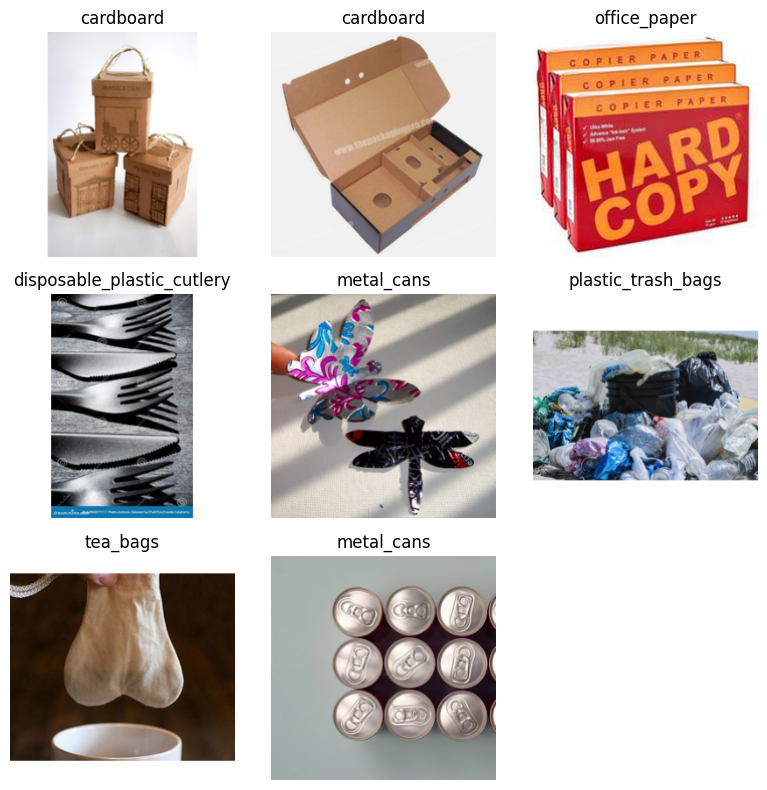

In [18]:
show_images(train_dataset, class_names)

# Training

## Setup functions for training and eval

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from google.colab import drive
import os
from sklearn.metrics import (
    accuracy_score, precision_score,
    recall_score, f1_score,
    ConfusionMatrixDisplay
)

def plot_loss_acc_training(history):
    """
    Plots training vs. validation accuracy and loss over epochs.

    Args:
        history: Keras History object returned by model.fit()
    """
    accuracy = history.history["accuracy"]
    val_accuracy = history.history["val_accuracy"]
    loss = history.history["loss"]
    val_loss = history.history["val_loss"]
    epochs = range(1, len(accuracy) + 1)

    plt.plot(epochs, accuracy, "bo", label="Training accuracy")
    plt.plot(epochs, val_accuracy, "b", label="Validation accuracy")
    plt.title("Training and validation accuracy")
    plt.legend()
    plt.figure()

    plt.plot(epochs, loss, "bo", label="Training loss")
    plt.plot(epochs, val_loss, "b", label="Validation loss")
    plt.title("Training and validation loss")
    plt.legend()
    plt.show()


def plot_predictions_grid(model, dataset, class_names, num_images=9):
    """
    Displays a grid of images with the model's predicted label and confidence.
    Titles are green for correct predictions and red for incorrect ones.

    Args:
        model:       Trained Keras/TF model
        dataset:     Batched tf.data.Dataset of (image, label) pairs
        class_names: List of class label strings
        num_images:  Number of images to display (default: 9)
    """
    cols = 3
    rows = (num_images + cols - 1) // cols

    images, true_labels = next(iter(
        dataset.unbatch().shuffle(buffer_size=1000).batch(num_images)
    ))

    images = images.numpy()
    true_labels = true_labels.numpy()

    plt.figure(figsize=(cols * 3, rows * 3))

    for i in range(num_images):
        img_array = np.expand_dims(images[i], axis=0)
        predictions = model.predict(img_array, verbose=0)
        predicted_index = np.argmax(predictions[0])
        confidence = np.max(predictions[0]) * 100

        plt.subplot(rows, cols, i + 1)
        plt.imshow(images[i].astype("uint8") if images[i].max() > 1 else images[i], cmap="gray")
        plt.axis("off")

        title = f"{class_names[predicted_index]} ({confidence:.1f}%)"
        true_label_i = int(np.argmax(true_labels[i]))
        color = "green" if predicted_index == true_label_i else "red"
        plt.title(title + f"\n[{class_names[true_label_i]}]", color=color, fontsize=10)

    plt.tight_layout()
    plt.show()


def _get_predictions_and_labels(model, test_dataset):
    """Single-pass collection of predictions and true labels to guarantee alignment."""
    all_preds  = []
    all_labels = []
    for images, labels in test_dataset:
        all_preds.append(model.predict_on_batch(images))
        all_labels.append(labels.numpy())
    predicted = np.argmax(np.concatenate(all_preds,  axis=0), axis=1)
    actual    = np.argmax(np.concatenate(all_labels, axis=0), axis=1)
    return predicted, actual


def evaluate_metrics(model, test_dataset):
    """
    Prints and returns Loss, Accuracy, Precision, Recall, and F1-Score.

    Args:
        model:        Trained Keras/TF model
        test_dataset: Batched tf.data.Dataset of (image, label) pairs
    """
    predicted_i, actual = _get_predictions_and_labels(model, test_dataset)
    test_loss, _        = model.evaluate(test_dataset, verbose=0)

    accuracy  = accuracy_score(actual, predicted_i)
    precision = precision_score(actual, predicted_i, average="weighted")
    recall    = recall_score(actual, predicted_i, average="weighted")
    f1        = f1_score(actual, predicted_i, average="weighted")

    print(f"Loss:      {test_loss:.4f}")
    print(f"Accuracy:  {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1-Score:  {f1:.4f}")

    return {"loss": test_loss, "accuracy": accuracy, "precision": precision, "recall": recall, "f1": f1}


def plot_confusion_matrix(model, test_dataset, class_names):
    """
    Displays a confusion matrix for the model's predictions.

    Args:
        model:        Trained Keras/TF model
        test_dataset: Batched tf.data.Dataset of (image, label) pairs
        class_names:  List of class label strings
    """
    predicted_i, actual = _get_predictions_and_labels(model, test_dataset)

    fig, ax = plt.subplots(figsize=(10, 10))
    ConfusionMatrixDisplay.from_predictions(
        actual,
        predicted_i,
        ax=ax,
        display_labels=class_names
    )
    plt.xticks(rotation=90)
    plt.title("Confusion Matrix")
    plt.show()


def save_model_to_drive(model, filename, drive_path="MyDrive/WasteClassifierModels"):
    """
    Mounts Google Drive and saves a trained Keras model to it.

    Args:
        model:      Trained Keras/TF model
        filename:   Name of the saved model file (e.g. "model.keras")
        drive_path: Folder path within Google Drive (default: "My Drive/models")
    """
    drive.mount("/content/drive", force_remount=False)

    save_dir = f"/content/drive/{drive_path}"
    os.makedirs(save_dir, exist_ok=True)

    full_path = f"{save_dir}/{filename}"
    model.save(full_path)
    print(f"Model saved to: {full_path}")


def load_model_from_drive(filename, drive_path="MyDrive/WasteClassifierModels"):
    """
    Mounts Google Drive and loads a Keras model from it.

    Args:
        filename:   Name of the saved model file (e.g. "model.keras")
        drive_path: Folder path within Google Drive (default: "My Drive/models")

    Returns:
        Loaded Keras model
    """
    drive.mount("/content/drive", force_remount=False)

    full_path = f"/content/drive/{drive_path}/{filename}"

    if not os.path.exists(full_path):
        raise FileNotFoundError(f"No model found at: {full_path}")

    model = keras.models.load_model(full_path)
    print(f"Model loaded from: {full_path}")
    return model

## ConvNeXt-Tiny — Two-Phase Fine-Tuning (23 Merged Classes)

Training directly on the **23 merged classes** (down from 30)

**5 key training improvements:**
1. **Stronger augmentation** — RandomBrightness + RandomContrast to fight the studio vs real-world domain gap
2. **Label smoothing (0.1)** — prevents overconfidence on similar classes
3. **Higher weight decay (0.05)** — matches ConvNeXt's original training recipe
4. **Increased dropout (0.4)** — forces the model to use more features instead of memorizing
5. **Class weight balancing** — compensates for classes with fewer images

### Imports and Stronger Data Augmentation

In [20]:
import tensorflow as tf
import numpy as np
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import ConvNeXtTiny

data_augmentation = keras.Sequential(
    [
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.15),
        layers.RandomZoom(0.2),
        layers.RandomBrightness(0.2),   # handles lighting differences
        layers.RandomContrast(0.2),      # handles studio vs outdoor contrast
    ]
)

### Compute class weights to handle imbalance from deduplication

In [21]:
import os
from sklearn.utils.class_weight import compute_class_weight

# Count images per class in the training set
train_dir = os.path.join(SPLIT_ROOT, "train")
class_counts = {}
for cls in sorted(os.listdir(train_dir)):
    cls_path = os.path.join(train_dir, cls)
    if os.path.isdir(cls_path):
        class_counts[cls] = len(os.listdir(cls_path))

print("Images per class in training set:")
for cls, count in sorted(class_counts.items(), key=lambda x: x[1]):
    print(f"  {cls}: {count}")

# Compute class weights — gives higher weight to classes with fewer images
all_labels = []
for i, cls in enumerate(class_names):
    all_labels.extend([i] * class_counts.get(cls, 0))

weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(all_labels),
    y=all_labels
)
class_weight_dict = {i: w for i, w in enumerate(weights)}

print(f"\nClass weights (min={min(weights):.3f}, max={max(weights):.3f}):")
for i, cls in enumerate(class_names):
    print(f"  {cls}: {class_weight_dict[i]:.3f}")

Images per class in training set:
  food_waste: 239
  styrofoam_food_containers: 267
  plastic_food_containers: 275
  plastic_cup_lids: 278
  aerosol_cans: 282
  plastic_detergent_bottles: 283
  disposable_plastic_cutlery: 288
  plastic_trash_bags: 289
  coffee_grounds: 293
  plastic_shopping_bags: 298
  tea_bags: 316
  plastic_straws: 323
  eggshells: 324
  office_paper: 348
  magazines: 356
  newspaper: 388
  shoes: 389
  clothing: 392
  cardboard: 530
  plastic_beverage_bottles: 580
  disposable_cups: 614
  metal_cans: 821
  glass_containers: 826

Class weights (min=0.474, max=1.637):
  aerosol_cans: 1.387
  cardboard: 0.738
  clothing: 0.998
  coffee_grounds: 1.335
  disposable_cups: 0.637
  disposable_plastic_cutlery: 1.359
  eggshells: 1.208
  food_waste: 1.637
  glass_containers: 0.474
  magazines: 1.099
  metal_cans: 0.477
  newspaper: 1.008
  office_paper: 1.124
  plastic_beverage_bottles: 0.675
  plastic_cup_lids: 1.407
  plastic_detergent_bottles: 1.383
  plastic_food_contai

### Load ConvNeXt-Tiny (frozen for Phase 1)

In [22]:
conv_next_base = ConvNeXtTiny(
    include_top=False,
    weights="imagenet",
    pooling="avg",
    input_shape=(IMG_SIZE + (3,)),
    include_preprocessing=True
)

# Phase 1: Freeze the base so we only train the top layers first
conv_next_base.trainable = False

111650432/111650432 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


### Build the model (dropout increased to 0.4)

In [23]:
inputs = keras.Input(shape=(IMG_SIZE + (3,)))
x = data_augmentation(inputs)
x = conv_next_base(x)
x = layers.Dropout(0.4)(x)    # Increased from 0.2 to reduce overfitting
outputs = layers.Dense(len(class_names), activation="softmax")(x)
conv_next_model = keras.Model(inputs=inputs, outputs=outputs)

In [24]:
conv_next_model.summary()

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ convnext_tiny (Functional)      │ (None, 768)            │    27,820,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 768)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 23)             │        17,687 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 27,837,815 (106.19 MB)

 Trainable params: 17,687 (69.09 KB)

 Non-trainable params: 27,820,128 (106.13 MB)

### Phase 1: Train top layers only (base frozen)
Short warm-up phase — 8 epochs to get the Dense layer ready

In [25]:
# Phase 1: Train only the top layers (base is frozen)
conv_next_model.compile(
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),  # Label smoothing
    optimizer=tf.keras.optimizers.AdamW(
        learning_rate=1e-3,
        weight_decay=0.05       # ConvNeXt's original weight decay
    ),
    metrics=["accuracy"]
)

callbacks_phase1 = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True
    ),
]

In [26]:
# Phase 1 Training
history_phase1 = conv_next_model.fit(
    train_dataset,
    epochs=8,
    validation_data=val_dataset,
    callbacks=callbacks_phase1,
    class_weight=class_weight_dict     # Class balancing
)

Epoch 1/8
282/282 ━━━━━━━━━━━━━━━━━━━━ 52s 117ms/step - accuracy: 0.5122 - loss: 2.0955 - val_accuracy: 0.7722 - val_loss: 1.2683
Epoch 2/8
282/282 ━━━━━━━━━━━━━━━━━━━━ 17s 58ms/step - accuracy: 0.7205 - loss: 1.4143 - val_accuracy: 0.8188 - val_loss: 1.1675
Epoch 3/8
282/282 ━━━━━━━━━━━━━━━━━━━━ 17s 58ms/step - accuracy: 0.7645 - loss: 1.2864 - val_accuracy: 0.8341 - val_loss: 1.1307
Epoch 4/8
282/282 ━━━━━━━━━━━━━━━━━━━━ 17s 59ms/step - accuracy: 0.7831 - loss: 1.2368 - val_accuracy: 0.8430 - val_loss: 1.1043
Epoch 5/8
282/282 ━━━━━━━━━━━━━━━━━━━━ 17s 58ms/step - accuracy: 0.7944 - loss: 1.2091 - val_accuracy: 0.8484 - val_loss: 1.0911
Epoch 6/8
282/282 ━━━━━━━━━━━━━━━━━━━━ 17s 58ms/step - accuracy: 0.8042 - loss: 1.1825 - val_accuracy: 0.8511 - val_loss: 1.0904
Epoch 7/8
282/282 ━━━━━━━━━━━━━━━━━━━━ 17s 59ms/step - accuracy: 0.8072 - loss: 1.1830 - val_accuracy: 0.8529 - val_loss: 1.0680
Epoch 8/8
282/282 ━━━━━━━━━━━━━━━━━━━━ 16s 58ms/step - accuracy: 0.8090 - loss: 1.1718 - val_acc

### Phase 2: Unfreeze everything and fine-tune
This is where the big accuracy gains happen

In [27]:
# Phase 2: Unfreeze the base model for full fine-tuning
conv_next_base.trainable = True

# Cosine decay: starts at 1e-5 and slowly decreases toward 0
total_steps = len(train_dataset) * 20  # 20 epochs worth of steps

conv_next_model.compile(
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),  # Label smoothing
    optimizer=tf.keras.optimizers.AdamW(
        learning_rate=tf.keras.optimizers.schedules.CosineDecay(
            initial_learning_rate=1e-5,
            decay_steps=total_steps
        ),
        weight_decay=0.05       # ConvNeXt's original weight decay
    ),
    metrics=["accuracy"]
)

callbacks_phase2 = [
    keras.callbacks.ModelCheckpoint(
        filepath="ConvNeXtTiny_merged.keras",
        save_best_only=True,
        monitor="val_loss"
    ),
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=7,
        restore_best_weights=True
    ),
]

# Phase 2 Training
history = conv_next_model.fit(
    train_dataset,
    epochs=20,
    validation_data=val_dataset,
    callbacks=callbacks_phase2,
    class_weight=class_weight_dict     # Class balancing
)

Epoch 1/20
282/282 ━━━━━━━━━━━━━━━━━━━━ 129s 300ms/step - accuracy: 0.8389 - loss: 1.0967 - val_accuracy: 0.8646 - val_loss: 1.0394
Epoch 2/20
282/282 ━━━━━━━━━━━━━━━━━━━━ 69s 244ms/step - accuracy: 0.8600 - loss: 1.0490 - val_accuracy: 0.8789 - val_loss: 1.0159
Epoch 3/20
282/282 ━━━━━━━━━━━━━━━━━━━━ 69s 244ms/step - accuracy: 0.8719 - loss: 1.0139 - val_accuracy: 0.8798 - val_loss: 0.9962
Epoch 4/20
282/282 ━━━━━━━━━━━━━━━━━━━━ 69s 244ms/step - accuracy: 0.8807 - loss: 0.9928 - val_accuracy: 0.8825 - val_loss: 0.9846
Epoch 5/20
282/282 ━━━━━━━━━━━━━━━━━━━━ 69s 243ms/step - accuracy: 0.8883 - loss: 0.9702 - val_accuracy: 0.8942 - val_loss: 0.9732
Epoch 6/20
282/282 ━━━━━━━━━━━━━━━━━━━━ 69s 244ms/step - accuracy: 0.8981 - loss: 0.9554 - val_accuracy: 0.8969 - val_loss: 0.9617
Epoch 7/20
282/282 ━━━━━━━━━━━━━━━━━━━━ 69s 243ms/step - accuracy: 0.9067 - loss: 0.9346 - val_accuracy: 0.9049 - val_loss: 0.9558
Epoch 8/20
282/282 ━━━━━━━━━━━━━━━━━━━━ 69s 243ms/step - accuracy: 0.9084 - loss: 

### Save the model

In [28]:
save_model_to_drive(conv_next_model, "ConvNeXtTiny.keras", drive_path="MyDrive/WasteClassifierModels")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Model saved to: /content/drive/MyDrive/WasteClassifierModels/ConvNeXtTiny.keras


### Load the model (if needed)

In [29]:
conv_next_model = load_model_from_drive("ConvNeXtTiny.keras")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Model loaded from: /content/drive/MyDrive/WasteClassifierModels/ConvNeXtTiny.keras


### Evaluate the model

In [30]:
evaluate_metrics(conv_next_model, test_dataset)

Loss:      0.8991
Accuracy:  0.9234
Precision: 0.9241
Recall:    0.9234
F1-Score:  0.9233


{'loss': 0.8991218209266663,
 'accuracy': 0.9234116623150566,
 'precision': 0.9241422904639646,
 'recall': 0.9234116623150566,
 'f1': 0.9232706338528915}

### Confusion Matrix

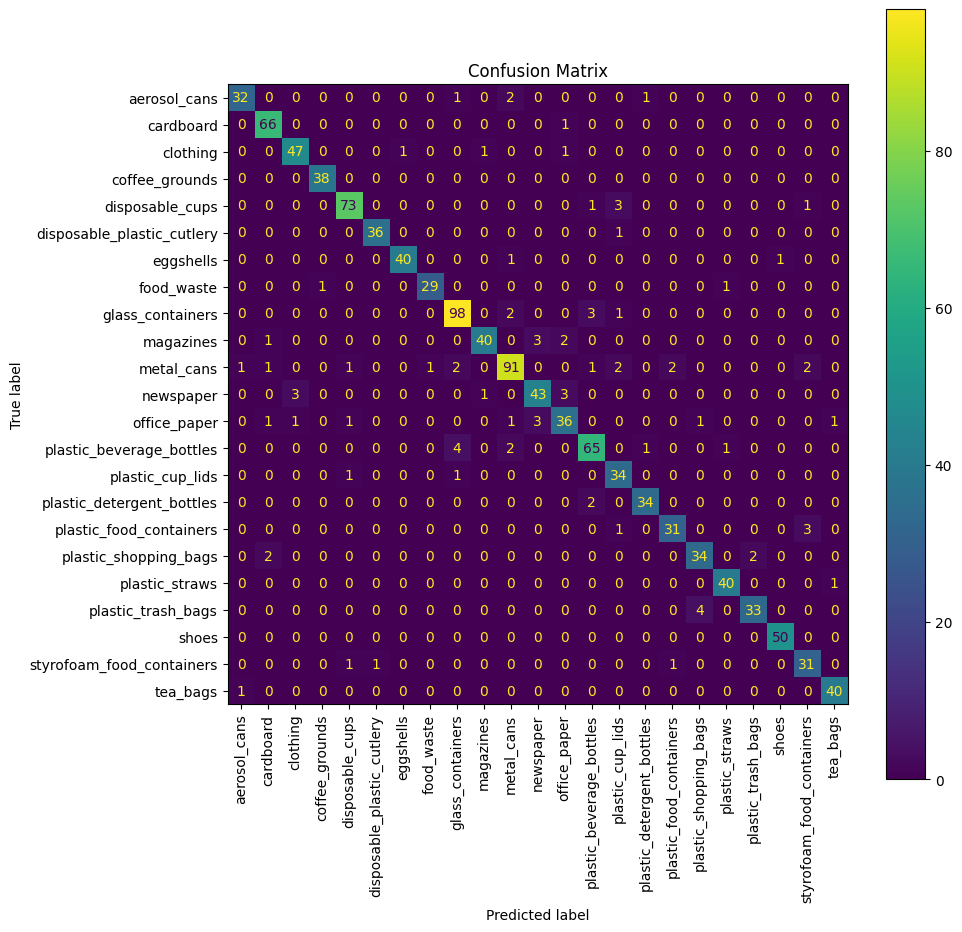

In [31]:
plot_confusion_matrix(conv_next_model, test_dataset, class_names)

### Plot Training Loss & Accuracy (Phase 2)

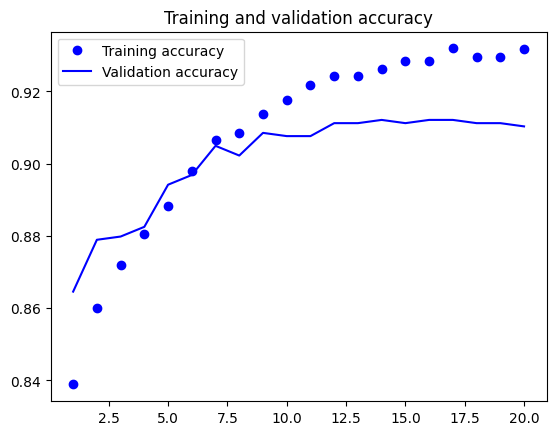

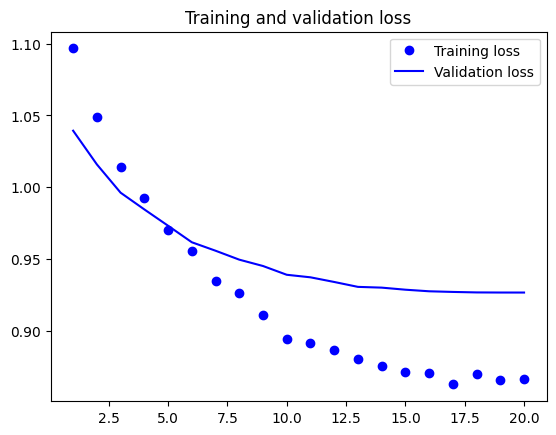

In [32]:
plot_loss_acc_training(history)

### Plot images with model predictions vs. actual labels

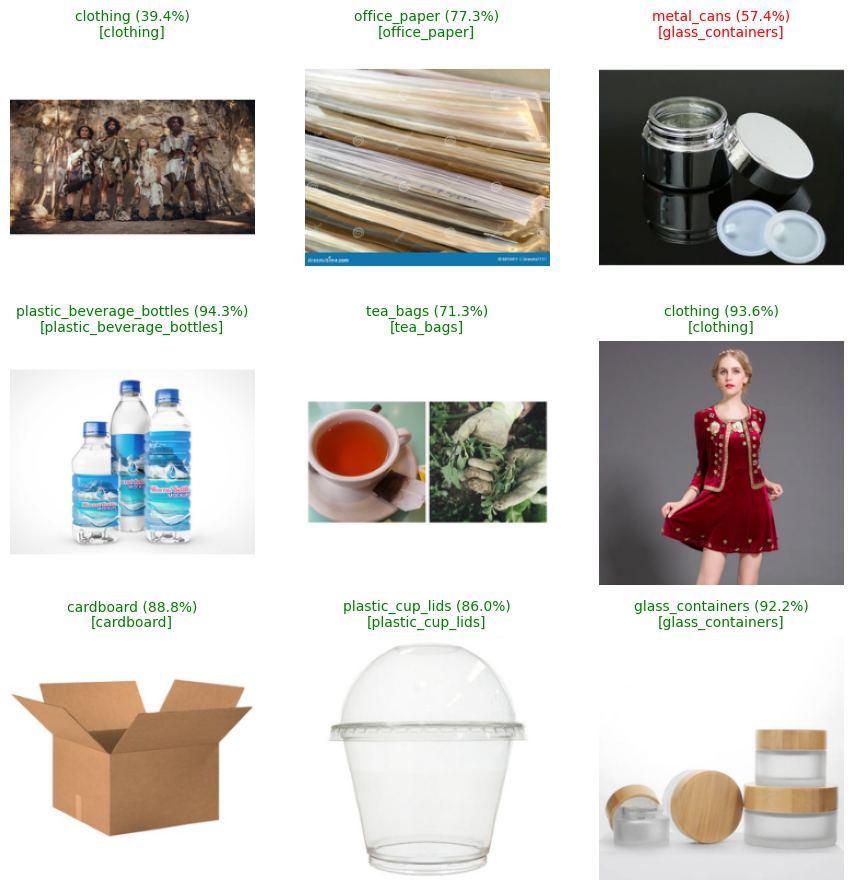

In [33]:
plot_predictions_grid(conv_next_model, test_dataset, class_names, num_images=9)